In [1]:
import math as m
from scipy import special as s
from matplotlib import pyplot as plt
import numpy as np

In [2]:
k_ev = 8.617*pow(10,-5)
tc = 300*pow(10,-7) #cm
area = 182.4 #6 inch wafer area
volume = tc*area
volume

0.0054719999999999994

In [11]:
cu_density = 8.5*pow(10,22) # atoms per cm cube
atoms_cu = volume*cu_density
atoms_cu

4.6511999999999993e+20

In [12]:
atoms_unit_area = atoms_cu/area
atoms_unit_area

2.5499999999999995e+18

In [22]:
def cu_diff(T):
    d_o = 4.7*pow(10,-3)
    exp = m.exp(-0.43/(k_ev*T))
    cu_diff = d_o*exp
    return cu_diff
cu_diff(673)

2.8307858906175496e-06

In [33]:
 cu_diff(673)

2.8307858906175496e-06

In [15]:
time = 900 #seconds 15 mins at 400 degree c
diff_length = m.sqrt(cu_diff(673)*time)
diff_length

0.0504748184895775

In [16]:
# complementary error fucntion
s.erfc(4)

1.541725790028002e-08

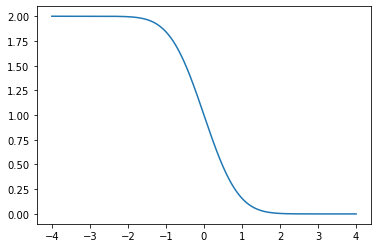

In [17]:
x = np.linspace(-4,4,1000)
erf = [s.erfc(i) for i in x]
plt.plot(x,erf)
plt.show()

In [18]:
# defining the solution for ficks equation
def fick(x):
    c_s = 4*pow(10,12)
    T = 673 #K (400 C)
    time = 900 #seconds 15 mins
    diff_len = m.sqrt(cu_diff(T)*time)
    return c_s*s.erfc(x/(2*diff_len))

In [19]:
x = np.linspace(0,0.2,1000)
fick_sol = [fick(i) for i in x]

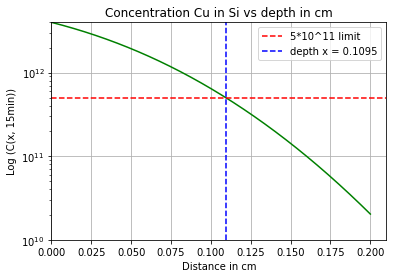

In [78]:
plt.plot(x,fick_sol, color = 'green')
plt.title('Concentration Cu in Si vs depth in cm')
plt.axhline(y=5*pow(10,11), linestyle = '--', color = 'red',label = '5*10^11 limit')
plt.axvline(x = 0.1095, linestyle = '--', color = 'blue',label = 'depth x = 0.1095')
plt.ylabel('Log (C(x, 15min))')
plt.xlabel('Distance in cm')
plt.grid()
plt.xlim(left=0)
plt.yscale('log')
plt.ylim(pow(10,10),4*pow(10,12))
plt.legend()
plt.show()

In [21]:
s.erfc(1.08476) # solution for [art 4]
# dose calculation
c_s = 4*pow(10,12)
dose = 1.13*diff_length*c_s
dose

228146179572.8903

In [4]:
c_s_al = 5*pow(10,18)
al_diff = 1.8*pow(10,-23)
time = 900 #seconds 15 mins
m.sqrt(al_diff*time)

1.2727922061357855e-10

In [22]:
#calculating Q4 for Al
# defining the solution for ficks equation
def fick_al(y):
    c_s_al = 5*pow(10,18)
    al_diff = 1.8*pow(10,-23)
    time = 900 #seconds 15 mins
    diff_len = m.sqrt(al_diff*time)
    return c_s_al*s.erfc(y/(2*diff_len))

In [23]:
 #solution for al diffucion in si 
al_diff = 1.8*pow(10,-23)
diff_len = m.sqrt(al_diff*900)
length = 2*diff_len*3.7665
length

9.587943688820873e-10

In [24]:
w = np.linspace(0,0.2*pow(10,-8),100)
fick_sol_al = [fick_al(i) for i in w]

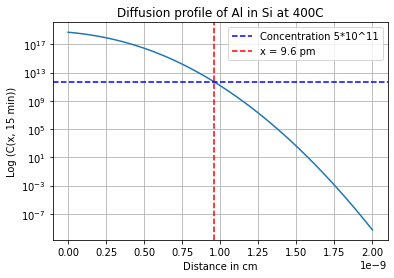

In [76]:
plt.plot(w,fick_sol_al)
plt.axhline(y = 5*pow(10,11), linestyle = '--', color = 'blue',label = 'Concentration 5*10^11')
plt.axvline(x = 9.59*pow(10,-10), linestyle = '--', color = 'red',label = 'x = 9.6 pm')
plt.title('Diffusion profile of Al in Si at 400C')
plt.ylabel('Log (C(x, 15 min))')
plt.xlabel('Distance in cm')
plt.grid()
plt.legend()
plt.yscale('log')

In [26]:
s.erfc(3.7665)

1.0004871591041357e-07

In [27]:
# dose calculation
c_s = 5*pow(10,19)
al_diff = 1.8*pow(10,-23)
diff_len = m.sqrt(al_diff*900)
dose = 1.13*diff_length*c_s
dose

2.8518272446611287e+18

In [111]:
def cu_tin_diff(T):
    d_o = 9.7*pow(10,-7)
    exp = m.exp(-2.8/(k_ev*T))
    cu_diff = d_o*exp
    return cu_diff
cu_tin_diff(673)

1.0425267881279781e-27

In [118]:
def fick_tin(y):
    c_s_tin = 4*pow(10,12)
    tin_diff = pow(10,-27)
    time = 900 #seconds 15 mins
    diff_len = m.sqrt(tin_diff*time)
    return c_s_tin*s.erfc(y/(2*diff_len))

In [122]:
z = np.linspace(0,10*pow(10,-11),1000)
fick_sol_tin = [fick_tin(i) for i in z]

(10000000000, 10000000000000)

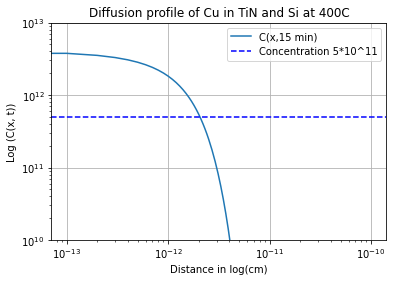

In [127]:
plt.plot(z,fick_sol_tin, label = 'C(x,15 min)')
# plt.plot(x,fick_sol, color = 'green', label = 'Cu in Si')
plt.axhline(y = 5*pow(10,11), linestyle = '--', color = 'blue',label = 'Concentration 5*10^11')
plt.title('Diffusion profile of Cu in TiN and Si at 400C')
plt.ylabel('Log (C(x, t))')
plt.xlabel('Distance in log(cm)')
plt.grid()
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylim(pow(10,10),pow(10,13))

In [125]:
m.sqrt(2.8*10**(-6)*900)

0.05019960159204453

In [7]:
def sol_sol(T):
    s_o = 5.51*pow(10,23)
    esp = m.exp(-1.49/(T*k_ev))
    return s_o*esp


43197875621.39979

In [35]:
c1 = sol_sol(673)
c2 = sol_sol(573)
c3 = sol_sol(773)

d1 =  cu_diff(673)
d2 = cu_diff(573)
d3 = cu_diff(773)

t1 = 900
t2 = (pow(c1/c2,2)*d1*t1)/d2
t3 = (pow(c1/c3,2)*d1*t1)/d3

In [36]:
t3

0.4473403611817283

In [39]:
t2/3600

7155.417584563047

In [38]:
1.13*c1*m.sqrt(d1*t1)

218257472663.03662